### Implementation of a CNN based Image Classifier using PyTorch:
#### 1. Importing Libraries and setting UP:
- torch(PyTorch) - Enables(To do something) building, training and running deep learning models using tensors.
- torchvision - Supplies standard vision datasets image transforms and visualization utilities.
- matplotlib.pyplot - Plots images, graphs and visual representations of data and results.
- numpy - Provides efficient array operations and mathematical utilities for data processing.
- ssl - Adjust security settings to bypass certificate errors during dataset downloads.
- Set up global plot parameters and SSL context to prevent download errors.

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
plt.rcParams['figure.figsize'] = 14, 6


#### 2. Defining Data Transformations and Loading CIFAR-10:
- We define a normalization transformation, scaling pixel values to have mean 0.5 and standard deviation 0.5 per channel.
- We then download and load the CIFAR-10 dataset for both training and testing, appling the transform.

In [4]:
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean = (0.5, 0.5, 0.5), std = (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root = "./CIFAR10/train",
                                             train = True,
                                             transform = normalize_transform,
                                             download = True)
test_dataset = torchvision.datasets.CIFAR10(root = "./CIFAR10/test",
                                            train = False,
                                            transform = normalize_transform,
                                            download = True)

#### 3. Creating Data Loaders:
- Set batch size to 128 for efficiency.
- Create data loaders for both train and test sets to manage batching and easy iteration.

In [5]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size)

#### 4. Visualizing Sample Images:
- Obtain a batch of images and labels from the train loader.
- Display a grid of 25 training for visual confirmation of the data pipeline.
  

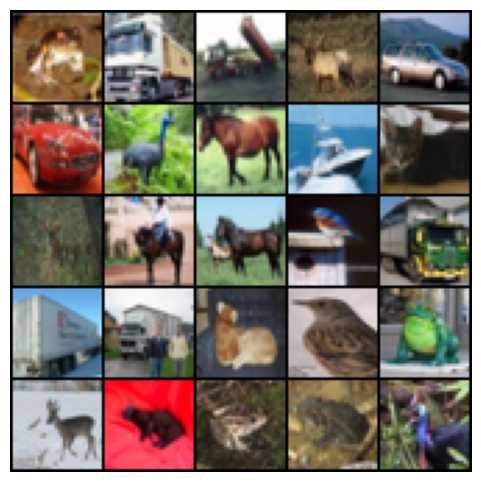

In [8]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize = True, padding = 1, nrow = 5).numpy(),
                        (1, 2, 0)))

plt.axis('off')
plt.show()

#### 5. Analyzing Dataset Class Distribution:
- Collect all labels from the training data.
- Count occurance for every class and visualize with a bar chart, revealing class balance.

In [ ]:
classes = []

for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extendy(y.tolist())

unique, counts = np.unique(classes, return_counts = True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

#### 6. Building the CNN Architecture:
- Build a convolutional neural network(CNN) using PyTorch modules.
  1. Three sets of convolution, activation(ReLU) and max pooling layers.
  2. Flatten the features and add two fully connected layers.
  3. Output layer predicts class scores for 10 classes.

In [ ]:
class CNN(torch.nn.module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            torch.nn.Flatten(),
            torch.nn.Linear(64 * 4 * 4, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)
            
        

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)

num_epochs = 50
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_loss_list = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss_list.append(train_loss / len(train_loader))
    print(f"Training loss = {train_loss_list[-1]}")

plt.plot(range(1, num_epochs + 1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()

test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

num_images = 5
y_true_name = [names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()